[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Data-Crew/transport-networks-lab/blob/main/Notebooks/Practica_guiada2_red_ciclovias.ipynb)

# Práctica guiada 2 — La red EcoBici como grafo

![grafos](https://github.com/PyMap/AUPY/blob/master/imagenes/grafos_introduccion.png?raw=1)

Una red de transporte es, en esencia, **nodos conectados por ejes**. En EcoBici
los nodos son las estaciones y los ejes, los viajes entre ellas.

Parece simple, pero esa traducción esconde tres decisiones de modelado que
cambian por completo el grafo que obtenemos:

| Decisión | Pregunta | Dónde la resolvemos |
|---|---|---|
| **Direccionalidad** | ¿Es lo mismo ir de A a B que de B a A? | Sección 1 |
| **Ejes múltiples** | Si el viaje A→B ocurre 500 veces, ¿es un eje o son 500? | Sección 1 |
| **Atributos** | ¿Qué información viaja en cada nodo y cada eje? | Secciones 2 y 4 |

El objetivo de esta práctica es que esas decisiones dejen de ser un detalle
técnico y se vuelvan una elección explícita.

## Setup

In [1]:
import math

import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
from shapely import wkt

plt.style.use("ggplot")
pd.set_option("display.max_columns", 30)

ANIOS = ["15", "16", "17", "18", "19"]

# Proyección plana local (CABA) — necesaria para plotear en metros
PROJ_CABA = (
    "+proj=tmerc +lat_0=-34.6297166 +lon_0=-58.4627 +k=0.9999980000000001 "
    "+x_0=100000 +y_0=100000 +ellps=intl +units=m +no_defs"
)

In [4]:
from google.colab import drive

drive.mount("/drive/")

# Única ruta a editar si movés los datos de lugar
DATA_DIR = "/drive/MyDrive/transport-networks-lab/Data"

In [5]:
# Viajes: un dataframe por año
# Fuente: https://data.buenosaires.gob.ar/dataset/bicicletas-publicas
viajes = {a: pd.read_csv(f"{DATA_DIR}/bici{a}_cdn.csv") for a in ANIOS}

# Estaciones: geometrías en WKT -> GeoDataFrame proyectado
est = pd.read_csv(f"{DATA_DIR}/estaciones_ecobici.csv", index_col=[0])
est["geometry"] = est["str_geom"].apply(wkt.loads)
estaciones = (
    gpd.GeoDataFrame(est.drop(columns="str_geom"), geometry="geometry", crs=4326)
    .to_crs(PROJ_CABA)
)

print(f"Estaciones: {len(estaciones)}")
print({a: len(d) for a, d in viajes.items()})

Estaciones: 199
{'15': 503867, '16': 716244, '17': 1886184, '18': 2970479, '19': 204107}


In [6]:
viajes["18"].head(3)

,bici_id_usuario,bici_Fecha_hora_retiro,bici_tiempo_uso,bici_nombre_estacion_origen,bici_estacion_origen,bici_nombre_estacion_destino,bici_estacion_destino,bici_sexo,bici_edad
0,107148.0,2018-12-31 23:56:42,39.0,Parque Lezama,6,Austria y French,200.0,MASCULINO,27.0
1,140759.0,2018-12-31 23:40:14,7.0,Cementerio de la Recoleta,166,Quintana,115.0,FEMENINO,65.0
2,391310.0,2018-12-31 23:31:39,2.0,Agüero,85,Ecuador,69.0,MASCULINO,24.0


## Sección 1. ¿Qué tipo de grafo es la red EcoBici?

![dirigido](https://github.com/PyMap/AUPY/blob/master/imagenes/dirigido_nodirigido.png?raw=1)

Un ciclista retira la bici en una estación y la devuelve en otra: el viaje
**tiene sentido**. Además, el mismo par de estaciones se recorre miles de veces
al año: hay **ejes repetidos**. NetworkX ofrece exactamente cuatro clases que
cruzan esas dos propiedades:

| Clase | ¿Distingue A→B de B→A? | ¿Admite ejes repetidos? |
|---|---|---|
| `Graph` | No | No |
| `DiGraph` | Sí | No |
| `MultiGraph` | No | Sí |
| `MultiDiGraph` | Sí | Sí |

En vez de discutirlo en abstracto, construyamos los cuatro y comparemos.

In [7]:
# Antes de modelar: ¿el dataset está completo?
d18 = viajes["18"]
print(f"Origen sin dato:  {d18.bici_estacion_origen.isna().sum()}")
print(f"Destino sin dato: {d18.bici_estacion_destino.isna().sum()}")

Origen sin dato:  0
Destino sin dato: 18456


Hay viajes sin estación de destino. Una estrategia razonable es suponer que
fueron **self-loops** (se retiró y devolvió en la misma estación), así que
imputamos el destino faltante con el origen y viceversa.

In [8]:
def construir_grafo(df, origen, destino, atributo,
                    constructor=nx.MultiDiGraph, coords=None):
    """Arma un grafo de estaciones (nodos) y viajes (ejes).

    No modifica `df`: trabaja sobre una copia de las columnas necesarias.

    Args:
        df: dataframe de viajes.
        origen, destino: columnas con las estaciones.
        atributo: columna a guardar como atributo de cada eje.
        constructor: clase de NetworkX (Graph, DiGraph, MultiGraph, MultiDiGraph).
        coords: dict {id_estacion: (y, x)}. Si se pasa, filtra los viajes a
            estaciones con coordenada conocida y la agrega como atributo 'coord'.

    Returns:
        Grafo de la clase indicada en `constructor`.
    """
    d = df[[origen, destino, atributo]].copy()

    # Imputación: destinos faltantes -> self-loop; atributo faltante -> promedio
    d[origen] = d[origen].fillna(d[destino])
    d[destino] = d[destino].fillna(d[origen])
    d[atributo] = d[atributo].fillna(d[atributo].mean())
    d = d.dropna(subset=[origen, destino])

    if coords is not None:
        d[[origen, destino]] = d[[origen, destino]].astype(int)
        d = d[d[origen].isin(coords) & d[destino].isin(coords)]

    G = nx.from_pandas_edgelist(
        d, source=origen, target=destino,
        edge_attr=atributo, create_using=constructor,
    )

    if coords is not None:
        nx.set_node_attributes(G, {n: coords[n] for n in G.nodes}, "coord")

    return G

In [9]:
CONSTRUCTORES = {
    "Graph": nx.Graph,
    "DiGraph": nx.DiGraph,
    "MultiGraph": nx.MultiGraph,
    "MultiDiGraph": nx.MultiDiGraph,
}

grafos_18 = {
    nombre: construir_grafo(
        viajes["18"],
        origen="bici_nombre_estacion_origen",
        destino="bici_nombre_estacion_destino",
        atributo="bici_tiempo_uso",
        constructor=clase,
    )
    for nombre, clase in CONSTRUCTORES.items()
}

comparacion = pd.DataFrame(
    {"nodos": G.number_of_nodes(), "ejes": G.number_of_edges()}
    for G in grafos_18.values()
).set_index(pd.Index(grafos_18.keys(), name="constructor"))

comparacion

,nodos,ejes
constructor,,
Graph,199,19575
DiGraph,199,38334
MultiGraph,199,2970479
MultiDiGraph,199,2970479


### ¿Cuántos ejes *deberíamos* esperar?

Mismos nodos, cuatro cantidades de ejes muy distintas. Para saber cuál tiene
sentido, calculemos el techo teórico de pares de estaciones conectables.

Si el orden **no** importa (`A-B` = `B-A`) es una **combinación**; si el orden
**sí** importa (`A→B` ≠ `B→A`) es una **permutación**.

In [10]:
n = comparacion.loc["MultiDiGraph", "nodos"]

print(f"Sin dirección (combinaciones): {math.comb(n, 2):>7,}")
print(f"Con dirección (permutaciones): {math.perm(n, 2):>7,}")

# Pares origen-destino únicos que realmente ocurren en los datos
pares_reales = (
    viajes["18"]
    .groupby(["bici_nombre_estacion_origen", "bici_nombre_estacion_destino"])
    .size()
    .reset_index(name="viajes")
)
print(f"Pares únicos observados:       {len(pares_reales):>7,}")
print(f"Viajes totales:                {pares_reales.viajes.sum():>7,}")

Sin dirección (combinaciones):  19,701
Con dirección (permutaciones):  39,402
Pares únicos observados:        38,334
Viajes totales:                2,952,023


Los pares observados se parecen al número de **permutaciones**, no al de
combinaciones. Primera conclusión: **el sentido importa**, y `Graph` está
perdiendo conexiones.

Pero ninguno de los dos números se acerca a los ~2 millones de viajes totales.
Veámoslo en un par concreto de estaciones.

In [11]:
A, B = "15 de Noviembre", "25 de Mayo"

def ejes_entre(G, a, b):
    return {
        "A→B": G.number_of_edges(a, b),
        "B→A": G.number_of_edges(b, a),
        "A→A": G.number_of_edges(a, a),
        "B→B": G.number_of_edges(b, b),
    }

pd.DataFrame({k: ejes_entre(G, A, B) for k, G in grafos_18.items()}).T

,A→B,B→A,A→A,B→B
Graph,1,1,1,1
DiGraph,1,1,1,1
MultiGraph,9,9,525,1313
MultiDiGraph,2,7,525,1313


In [12]:
# ¿Cuántos viajes hay realmente entre ese par?
pares_reales[
    pares_reales.bici_nombre_estacion_origen.isin([A, B])
    & pares_reales.bici_nombre_estacion_destino.isin([A, B])
]

,bici_nombre_estacion_origen,bici_nombre_estacion_destino,viajes
0,15 de Noviembre,15 de Noviembre,494
1,15 de Noviembre,25 de Mayo,2
190,25 de Mayo,15 de Noviembre,7
191,25 de Mayo,25 de Mayo,1246


### Conclusión de modelado

- `Graph` colapsa `A→B` y `B→A` en un solo eje: **pierde el sentido del viaje**.
- `DiGraph` respeta el sentido pero guarda **un solo eje por par**: pierde el volumen.
- `MultiGraph` conserva el volumen pero **no distingue el sentido**.
- `MultiDiGraph` conserva ambas cosas: es el único que representa
  *todos los viajes de todos los usuarios*.

Trabajamos de acá en adelante con **`MultiDiGraph`**.

> Ojo: "correcto" depende de la pregunta. Si sólo nos interesa **qué estaciones
> están conectadas** (y no cuántas veces), `Graph` es más liviano y suficiente.
> El modelo se elige según lo que se quiere medir.

In [13]:
# Un MultiDiGraph por año
G_anio = {
    a: construir_grafo(
        viajes[a],
        origen="bici_nombre_estacion_origen",
        destino="bici_nombre_estacion_destino",
        atributo="bici_tiempo_uso",
    )
    for a in ANIOS
}

## Sección 2. Ubicar la red en el espacio

Hasta acá el grafo es una estructura abstracta: sabemos quién se conecta con
quién, pero no **dónde**. Para dibujarlo sobre el mapa necesitamos sumar las
coordenadas de cada estación como atributo de nodo.

Como el archivo de estaciones se identifica por `NRO_EST`, acá construimos los
grafos usando el **id numérico** en vez del nombre.

In [14]:
# dict {id_estacion: (y, x)} en coordenadas proyectadas
coords = dict(
    zip(estaciones.NRO_EST, zip(estaciones.geometry.y, estaciones.geometry.x))
)

G_geo = {
    a: construir_grafo(
        viajes[a],
        origen="bici_estacion_origen",
        destino="bici_estacion_destino",
        atributo="bici_tiempo_uso",
        constructor=nx.Graph,   # para dibujar alcanza con adyacencias
        coords=coords,
    )
    for a in ANIOS
}

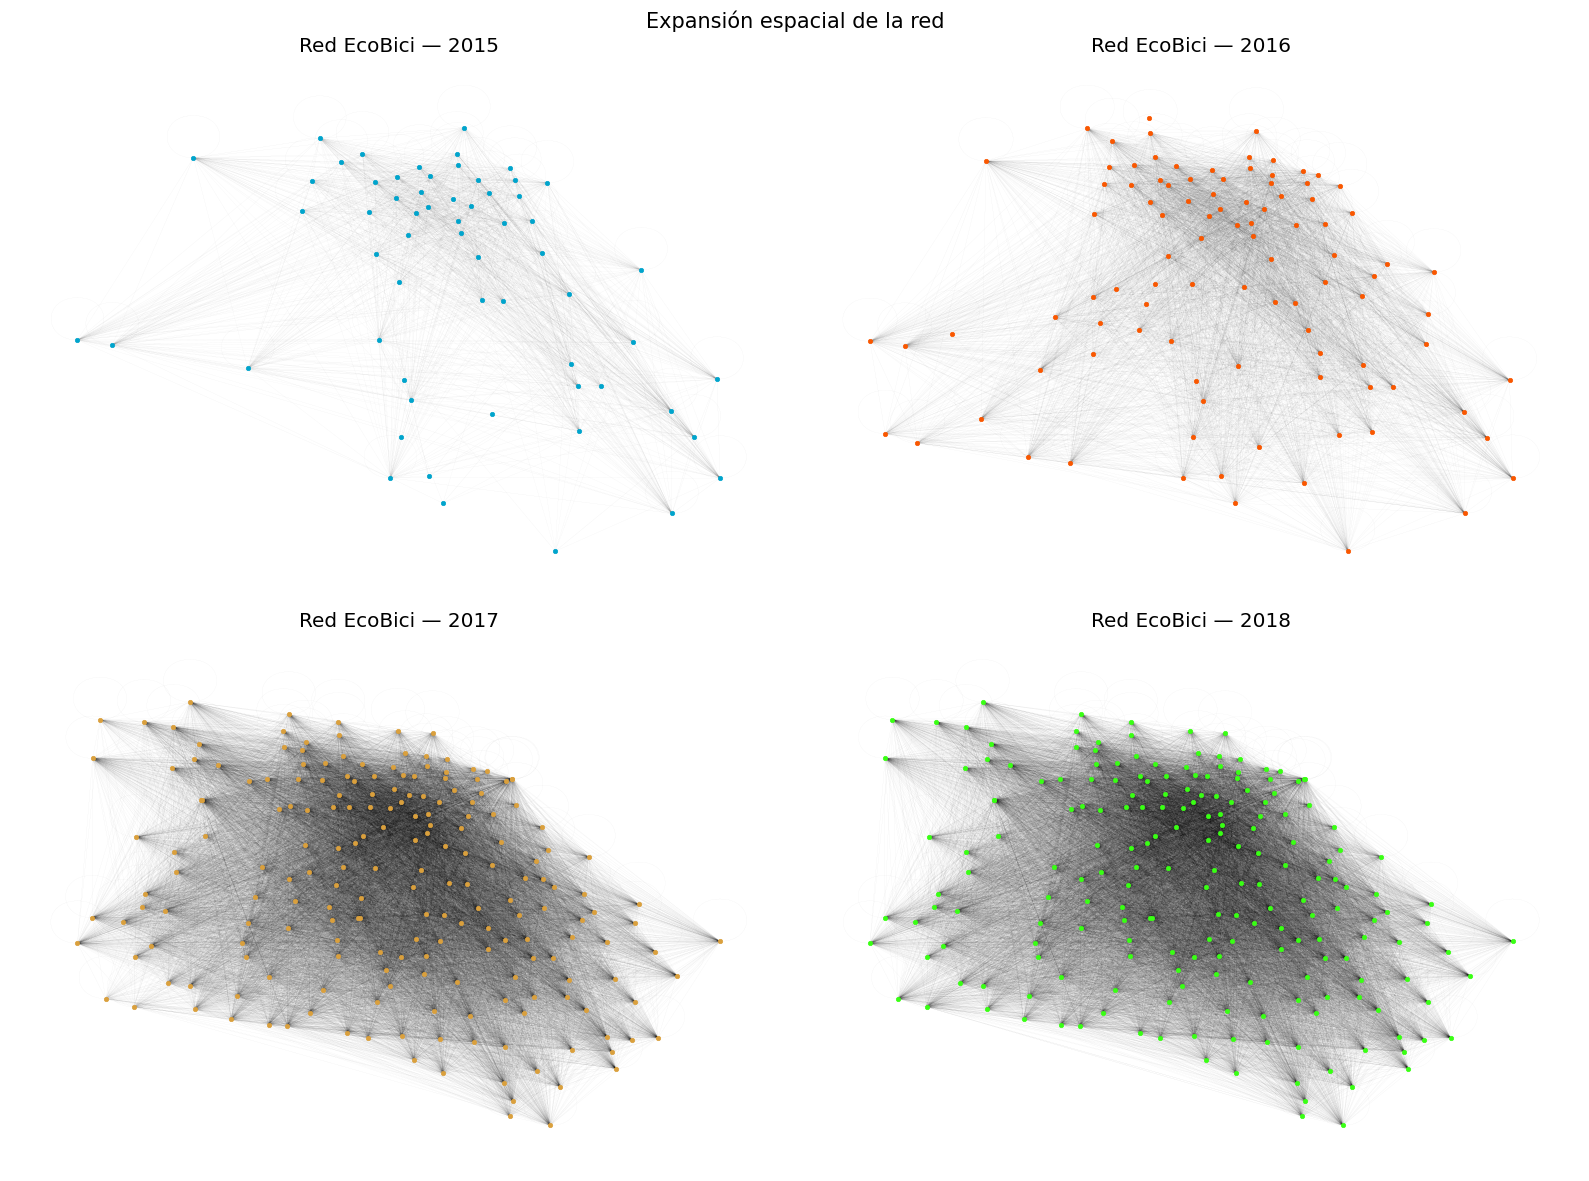

In [16]:
def plotear_red(G, ax, titulo, color="#00203FFF"):
    pos = nx.get_node_attributes(G, "coord")
    nx.draw_networkx_edges(G, pos=pos, width=0.01, ax=ax)
    nx.draw_networkx_nodes(G, pos=pos, node_size=10, node_color=color, ax=ax)
    ax.set_axis_off()
    ax.set_title(titulo)


COLORES = ["#00A4CCFF", "#F95700FF", "#DAA03DFF", "#39FF14"]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, a, c in zip(axes.flat, ["15", "16", "17", "18"], COLORES):
    plotear_red(G_geo[a], ax, f"Red EcoBici — 20{a}", color=c)

fig.suptitle("Expansión espacial de la red", fontsize=15)
plt.tight_layout()
plt.show()

### Ejercitación 1

La visualización de arriba usa `nx.Graph` (adyacencias). Reescribila para que
el **tamaño de cada nodo** sea proporcional a su grado en el `MultiDiGraph`
correspondiente, de modo que se vea no sólo dónde está cada estación sino
cuánto se usa.

*Pista: `nx.draw_networkx_nodes` acepta una lista en `node_size`, en el mismo
orden que `G.nodes()`.*

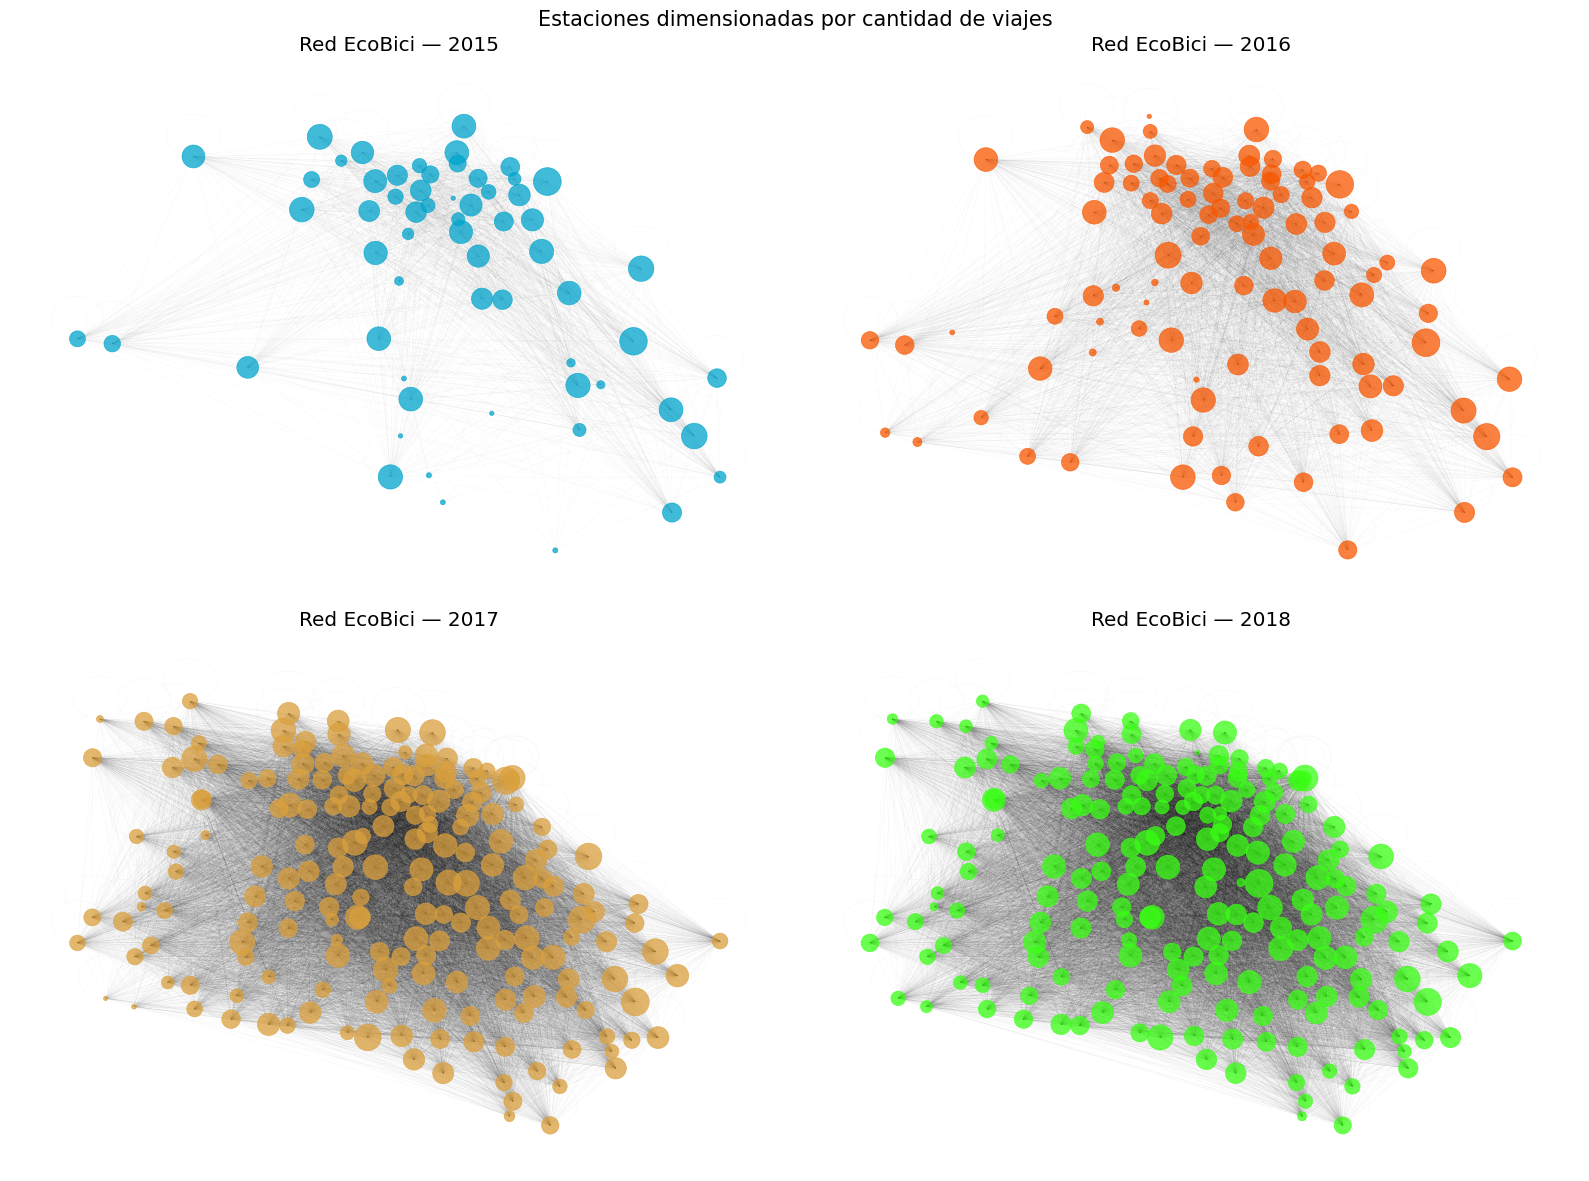

In [31]:
#@title Solucion
# El MultiDiGraph sólo se usa para CONTAR viajes, nunca para dibujar ejes
G_geo_multi = {
    a: construir_grafo(
        viajes[a],
        origen="bici_estacion_origen",
        destino="bici_estacion_destino",
        atributo="bici_tiempo_uso",
        constructor=nx.MultiDiGraph,
        coords=coords,
    )
    for a in ["15", "16", "17", "18"]
}


def tamanos_por_grado(nodos, G_grados, minimo=10, maximo=400):
    """Escala el grado de cada nodo a un rango de tamaños ploteables.

    Usa raíz cuadrada porque el ojo compara *áreas*: sin eso, una estación
    con el doble de viajes se ve cuatro veces más grande.

    Args:
        nodos: iterable de nodos, en el orden en que se van a dibujar.
        G_grados: grafo del que se lee el grado (el MultiDiGraph).

    Returns:
        Array de tamaños alineado con `nodos`.
    """
    grados = np.array([G_grados.degree(n) for n in nodos], dtype=float)
    escala = np.sqrt(grados)
    norm = (escala - escala.min()) / (escala.max() - escala.min())
    return minimo + norm * (maximo - minimo)


fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for ax, a, c in zip(axes.flat, ["15", "16", "17", "18"], COLORES):
    G = G_geo[a]              # Graph: pocas adyacencias -> dibuja rápido
    pos = nx.get_node_attributes(G, "coord")
    nodos = list(G.nodes())

    nx.draw_networkx_edges(G, pos=pos, width=0.01, ax=ax)
    nx.draw_networkx_nodes(
        G, pos=pos, nodelist=nodos,
        node_size=tamanos_por_grado(nodos, G_geo_multi[a]),
        node_color=c, alpha=0.75, ax=ax,
    )
    ax.set_axis_off()
    ax.set_title(f"Red EcoBici — 20{a}")

fig.suptitle("Estaciones dimensionadas por cantidad de viajes", fontsize=15)
plt.tight_layout()
plt.show()


## Sección 3. Métricas de la red

### 3.1. Evolución de nodos, ejes y grado promedio

El **grado de un nodo** es la cantidad de ejes que lo tocan. En un grafo
dirigido se descompone en *in-degree* (entrantes) y *out-degree* (salientes),
y el grado promedio de toda la red es `2·E / N`.

In [17]:
evolucion = pd.DataFrame(
    {
        "anio": f"20{a}",
        "nodos": G.number_of_nodes(),
        "ejes": G.number_of_edges(),
        "grado_promedio": round(2 * G.number_of_edges() / G.number_of_nodes(), 1),
    }
    for a, G in G_anio.items()
).set_index("anio")

evolucion

,nodos,ejes,grado_promedio
anio,,,
2015,66,503867,15268.7
2016,102,716244,14044.0
2017,202,1886184,18675.1
2018,199,2970479,29854.1
2019,170,204107,2401.3


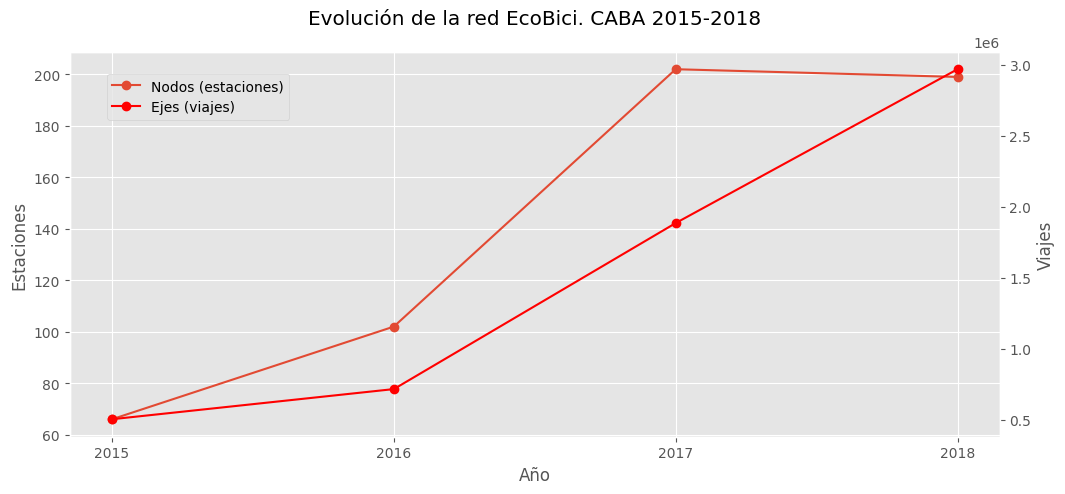

      nodos   ejes
anio              
2016   54.5   42.1
2017   98.0  163.3
2018   -1.5   57.5


In [18]:
# 2019 sólo llega hasta febrero: lo dejamos afuera de la serie
serie = evolucion.drop(index="2019")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(serie.index, serie.nodos, marker="o", label="Nodos (estaciones)")
ax.set_ylabel("Estaciones")
ax.set_xlabel("Año")

ax2 = ax.twinx()
ax2.plot(serie.index, serie.ejes, marker="o", color="r", label="Ejes (viajes)")
ax2.set_ylabel("Viajes")
ax2.grid(False)

fig.legend(loc="upper left", bbox_to_anchor=(0.15, 0.85))
plt.title("Evolución de la red EcoBici. CABA 2015-2018", y=1.05)
plt.show()

crec = serie.pct_change().mul(100).round(1)
print(crec[["nodos", "ejes"]].dropna())

La red crece en estaciones, pero los viajes crecen mucho más rápido: no es sólo
una red más grande, es una red **más usada**.

### 3.2. Centralidad: ¿qué estaciones concentran los viajes?

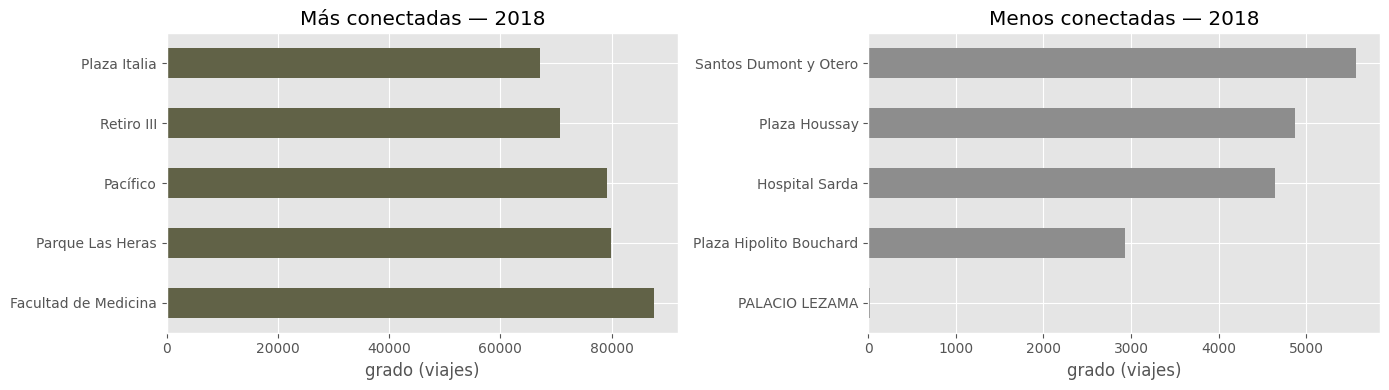

In [19]:
def ranking_grado(G, top=5, ascendente=False):
    """Devuelve las `top` estaciones por grado (o las de menor grado)."""
    return (
        pd.Series(dict(G.degree()), name="grado")
        .sort_values(ascending=ascendente)
        .head(top)
    )


fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ranking_grado(G_anio["18"], top=5).plot.barh(
    ax=axes[0], color="#616247FF", title="Más conectadas — 2018"
)
ranking_grado(G_anio["18"], top=5, ascendente=True).plot.barh(
    ax=axes[1], color="#8d8d8d", title="Menos conectadas — 2018"
)

for ax in axes:
    ax.set_xlabel("grado (viajes)")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

### 3.3. In-degree y out-degree

`Facultad de Medicina` encabeza el ranking. ¿Es una estación de la que se sale,
a la que se llega, o ambas?

In [20]:
def grados(G):
    """Devuelve un df con in_degree, out_degree y grado total por estación."""
    return pd.DataFrame(
        {
            "in_degree": dict(G.in_degree()),
            "out_degree": dict(G.out_degree()),
            "grado": dict(G.degree()),
        }
    ).rename_axis("estacion")


g18 = grados(G_anio["18"])
g18.loc[["Facultad de Medicina"]]

,in_degree,out_degree,grado
estacion,,,
Facultad de Medicina,44003,43606,87609


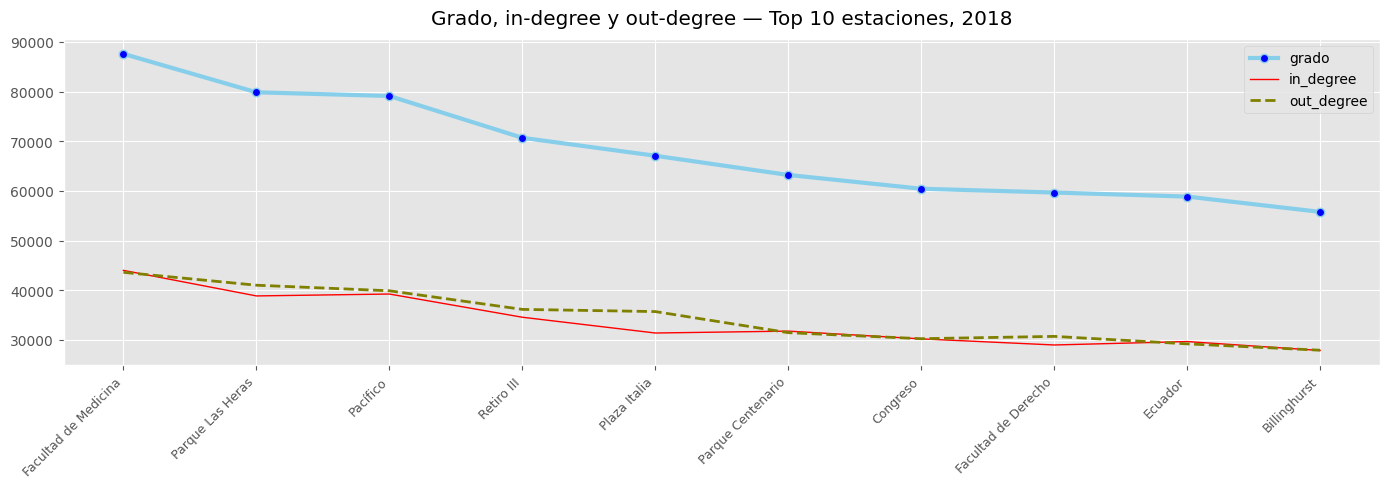

In [21]:
top10 = g18.sort_values("grado", ascending=False).head(10)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(top10.index, top10.grado, marker="o", linewidth=3,
        color="skyblue", markerfacecolor="blue", label="grado")
ax.plot(top10.index, top10.in_degree, color="red", linewidth=1, label="in_degree")
ax.plot(top10.index, top10.out_degree, color="olive", linewidth=2,
        linestyle="dashed", label="out_degree")

plt.xticks(rotation=45, ha="right", fontsize=9)
plt.title("Grado, in-degree y out-degree — Top 10 estaciones, 2018", y=1.02)
plt.legend()
plt.tight_layout()
plt.show()

Las curvas de entrada y salida son casi idénticas: la red está **balanceada**.
Cada bici que sale de una estación tiende a volver en cantidades similares —
razonable en un sistema donde el uso es mayormente pendular.

### 3.4. Distribución de grados y matriz de adyacencia

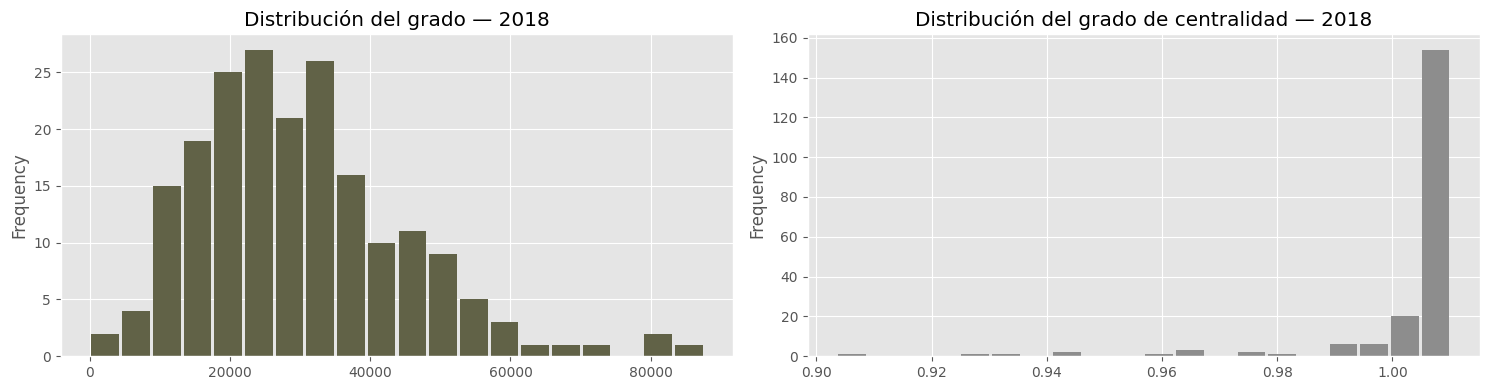

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

pd.Series(dict(G_anio["18"].degree())).plot.hist(
    bins=20, rwidth=0.9, color="#616247FF", ax=axes[0],
    title="Distribución del grado — 2018",
)
pd.Series(nx.degree_centrality(G_geo["18"])).plot.hist(
    bins=20, rwidth=0.9, color="#8d8d8d", ax=axes[1],
    title="Distribución del grado de centralidad — 2018",
)

plt.tight_layout()
plt.show()

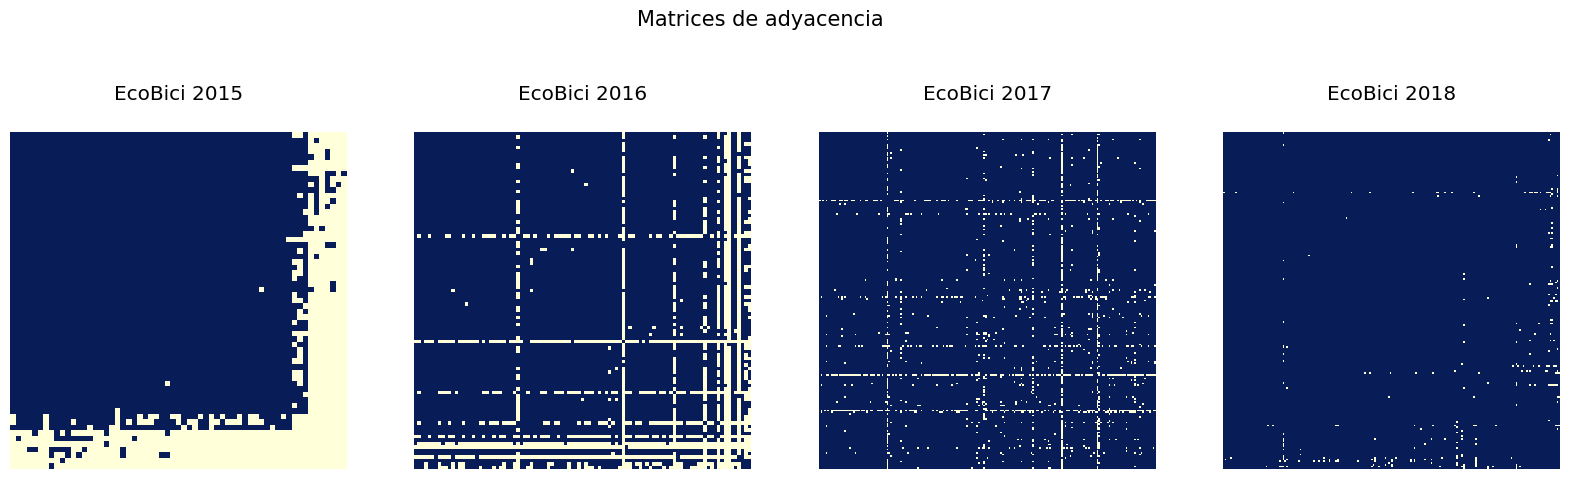

In [23]:
fig, axes = plt.subplots(1, 4, figsize=(20, 6))

for ax, a in zip(axes, ["15", "16", "17", "18"]):
    ax.matshow(nx.to_numpy_array(G_geo[a]), cmap="YlGnBu")
    ax.set_axis_off()
    ax.set_title(f"EcoBici 20{a}")

fig.suptitle("Matrices de adyacencia", fontsize=15)
plt.show()

La matriz se va "llenando" año a año: cada vez más pares de estaciones tienen
al menos un viaje entre sí. La red no sólo suma nodos, se vuelve **más densa**.

## Sección 4. Patrones de uso

Todo lo anterior mira la red como un agregado anual. Pero una red de transporte
**respira**: no es la misma a las 8 de la mañana que a las 3 de la tarde.

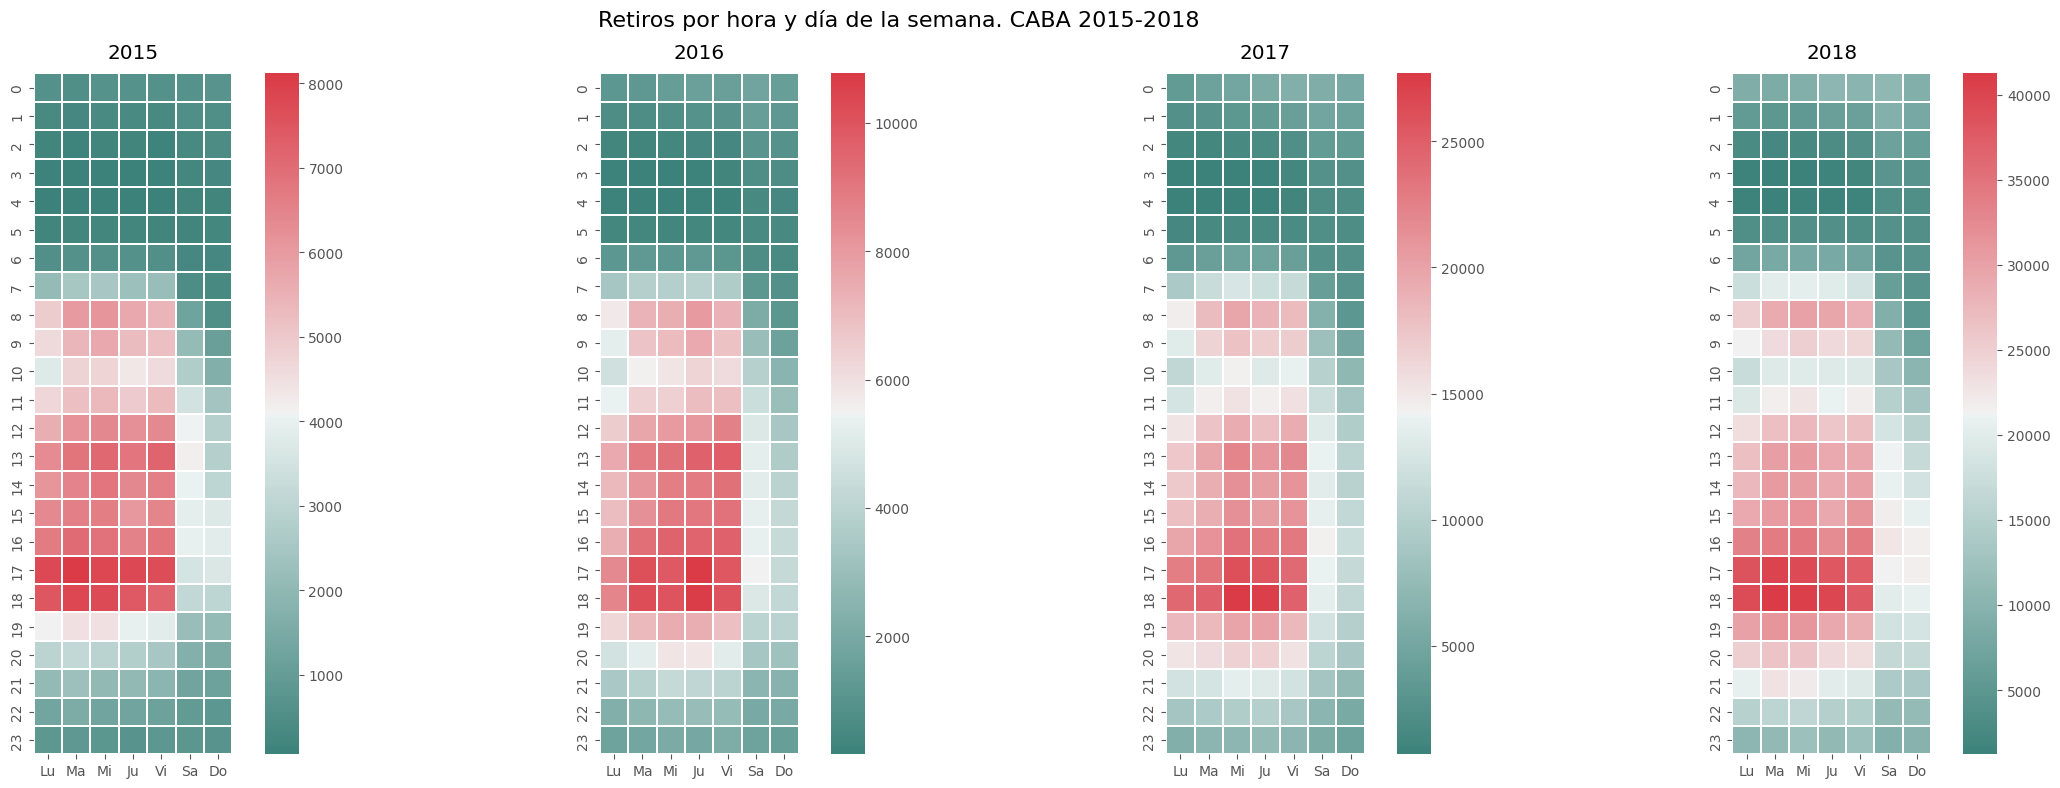

In [24]:
fig, axes = plt.subplots(1, 4, figsize=(24, 8))
dias = ["Lu", "Ma", "Mi", "Ju", "Vi", "Sa", "Do"]

for ax, a in zip(axes, ["15", "16", "17", "18"]):
    retiro = pd.to_datetime(viajes[a].bici_Fecha_hora_retiro)
    pivot = (
        viajes[a]
        .groupby([retiro.dt.hour, retiro.dt.weekday])
        .size()
        .unstack(fill_value=0)
    )
    sns.heatmap(pivot, square=True, linewidths=0.1, ax=ax,
                cmap=sns.diverging_palette(180, 10, as_cmap=True))
    ax.set_title(f"20{a}", y=1.01)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticklabels(dias, rotation=0)

fig.suptitle("Retiros por hora y día de la semana. CABA 2015-2018", fontsize=16)
plt.tight_layout()
plt.show()

Se ven con claridad los dos picos de hora punta de lunes a viernes y un patrón
completamente distinto los fines de semana: **uso pendular vs. uso recreativo**.

### 4.1. Recortes temporales

In [25]:
def preparar(df, filtros=None):
    """Agrega atributos temporales y aplica filtros opcionales.

    Args:
        df: dataframe de viajes de un año.
        filtros: dict {columna: [valor]} para igualdad, o
            {columna: [desde, hasta]} para rango. Se aplican todos.

    Returns:
        Dataframe con columnas mes/fecha/hora/dia_semana, filtrado.
    """
    d = df.copy()
    retiro = pd.to_datetime(d.bici_Fecha_hora_retiro)

    d["mes"] = retiro.dt.month
    d["fecha"] = retiro.dt.normalize()
    d["hora"] = retiro.dt.hour
    d["dia_semana"] = retiro.dt.day_name()

    for col, vals in (filtros or {}).items():
        if len(vals) == 1:
            d = d[d[col] == vals[0]]
        else:
            d = d[d[col].between(min(vals), max(vals))]

    return d


diciembre18 = preparar(viajes["18"], filtros={"mes": [12]})
navidad18 = preparar(viajes["18"], filtros={"fecha": ["2018-12-24", "2018-12-31"]})

print(f"Diciembre 2018:      {len(diciembre18):>7,} viajes")
print(f"24 al 31 de dic '18: {len(navidad18):>7,} viajes")

Diciembre 2018:      166,585 viajes
24 al 31 de dic '18:  25,981 viajes


### 4.2. La red hora a hora

Guardamos la hora como **atributo de cada eje**. Eso nos permite filtrar el
grafo por franja horaria y calcular el grado de cada estación en cada momento
del día.

In [26]:
def grafo_por_hora(df):
    """MultiDiGraph con la hora de retiro como atributo de cada eje."""
    return nx.from_pandas_edgelist(
        df,
        source="bici_nombre_estacion_origen",
        target="bici_nombre_estacion_destino",
        edge_attr="hora",
        create_using=nx.MultiDiGraph,
    )


def grados_por_hora(G):
    """Grado de cada estación en cada una de las 24 horas del día."""
    salida = []
    for hora in range(24):
        ejes = [(u, v, k) for u, v, k, d in G.edges(keys=True, data=True)
                if d["hora"] == hora]
        if not ejes:
            continue
        sub = G.edge_subgraph(ejes)
        salida.append(grados(sub).assign(hora=hora).reset_index())

    return pd.concat(salida, ignore_index=True)


G_dic = grafo_por_hora(diciembre18)
grado_horario = grados_por_hora(G_dic)
grado_horario.head()

,estacion,in_degree,out_degree,grado,hora
0,Parque Lezama,1,1,2,0
1,Austria y French,60,55,115,0
2,Cementerio de la Recoleta,48,53,101,0
3,Quintana,11,17,28,0
4,Agüero,49,43,92,0


In [29]:
# Sumamos la geometría de cada estación para poder mapearla
gdf = gpd.GeoDataFrame(
    grado_horario.merge(
        estaciones[["NOMBRE", "geometry"]],
        left_on="estacion", right_on="NOMBRE", how="inner",
    ),
    geometry="geometry",
).to_crs(4326)

fig = px.scatter_map(          # antes: scatter_mapbox
    gdf,
    lat=gdf.geometry.y, lon=gdf.geometry.x,
    hover_name="estacion",
    animation_frame="hora",
    size="out_degree",
    color_discrete_sequence=["#F05E23"],
    opacity=0.9, zoom=11, height=600,
    map_style="carto-darkmatter",   # antes: mapbox_style, y va acá adentro
)
fig.update_layout(
    title_text="Retiros de bicicletas por estación y hora — Diciembre 2018",
    margin={"r": 1, "t": 75, "l": 0, "b": 0},
)
fig.show()

### Ejercitación 2

El mapa anima el `out_degree` (retiros). Compará **retiros contra devoluciones**
para detectar estaciones desbalanceadas.

1. Calculá `in_degree - out_degree` por estación y hora.
2. Identificá las 5 estaciones con mayor desbalance en la hora pico de la mañana.
3. ¿Qué implicancia operativa tiene? *(Pista: alguien tiene que redistribuir
   esas bicicletas.)*

In [35]:
#@title Solucion item 1
# 1. Balance por estación y hora
grado_horario["balance"] = grado_horario.in_degree - grado_horario.out_degree

# Chequeo de consistencia: cada viaje sale de algún lado y llega a otro,
# así que el balance de TODA la red en cada hora tiene que ser cero.
print(grado_horario.groupby("hora").balance.sum().abs().max())

0


In [33]:
#@title Solucion item 2
# 2. Hora pico de la mañana: la de mayor actividad total entre las 6 y las 11
pico = grado_horario[grado_horario.hora.between(6, 11)].groupby("hora").grado.sum().idxmax()
print(f"Hora pico de la mañana: {pico}:00 hs\n")

h = grado_horario[grado_horario.hora == pico].set_index("estacion")

print("Se VACÍAN (salen más bicis de las que llegan):")
print(h.balance.nsmallest(5).to_string())

print("\nSe LLENAN (llegan más bicis de las que salen):")
print(h.balance.nlargest(5).to_string())

Hora pico de la mañana: 8:00 hs

Se VACÍAN (salen más bicis de las que llegan):
estacion
Retiro III               -82
Pasco                    -52
Congreso                 -51
Hospital Francés         -46
Facultad de Psicologia   -46

Se LLENAN (llegan más bicis de las que salen):
estacion
Vera Peñaloza       110
25 de Mayo          110
Ingeniero Butty      99
Azopardo y Chile     95
Bouchard             88


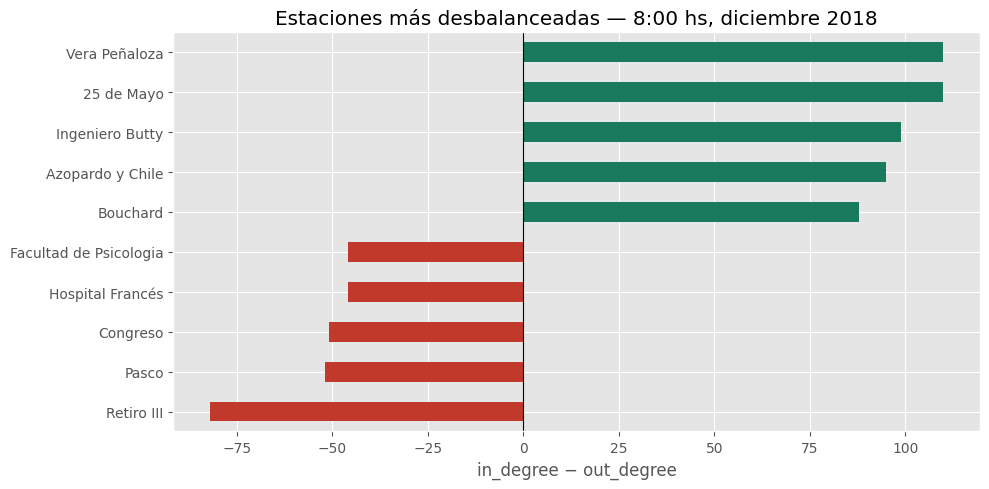

In [34]:
#@title Solucion item 3
# 3. Visualización del desbalance
top = pd.concat([h.balance.nsmallest(5), h.balance.nlargest(5)]).sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
top.plot.barh(ax=ax, color=["#C0392B" if v < 0 else "#1A7A5E" for v in top])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("in_degree − out_degree")
ax.set_ylabel("")
ax.set_title(f"Estaciones más desbalanceadas — {pico}:00 hs, diciembre 2018")
plt.tight_layout()
plt.show()

In [36]:
#@title 📌 Ver conclusiones { display-mode: "form" }
from IPython.display import Markdown, display

display(Markdown("""
### Conclusiones

**Por qué el chequeo tiene que dar exactamente 0**

Cada viaje suma 1 al `out_degree` de su origen y 1 al `in_degree` de su destino.
Al calcular `in_degree − out_degree` y sumar sobre todas las estaciones, cada
viaje se cuenta una vez con signo positivo y una vez con signo negativo: el
total se cancela. Por eso **no es un resultado, es un test**.

Si diera distinto de cero no habría un hallazgo interesante, habría un bug: un
`merge` que perdió filas, un filtro aplicado a origen pero no a destino, o
estaciones que quedaron fuera del grafo. Ojo: que dé cero confirma que *no se
perdieron datos*, no que el análisis esté bien planteado.

**Qué muestran los números**

A las 8 de la mañana la red no está en equilibrio, está en pleno movimiento
pendular. Las cinco estaciones que **se llenan** (Vera Peñaloza, 25 de Mayo,
Ingeniero Butty, Azopardo y Chile, Bouchard) están todas en el corredor de
oficinas de Catalinas y Puerto Madero.

Las que **se vacían** responden a otra lógica. Retiro III encabeza el ranking
porque es la terminal de trenes y colectivos: miles de personas llegan desde el
conurbano y toman una bici para el último tramo. El resto (Pasco, Congreso,
Hospital Francés, Facultad de Psicología) son estaciones de origen residencial.

En una frase: **la red transporta gente desde donde llega hasta donde trabaja**,
y lo hace en una sola dirección durante toda la hora pico.

**Un detalle que no es obvio**

Como el total da cero, superávit y déficit son iguales en magnitud. Pero no
están distribuidos igual: el superávit se concentra en pocas estaciones con
valores altos (110, 110, 99...), mientras que el déficit se reparte entre
muchas más estaciones con valores menores. Los destinos son pocos y
concentrados; los orígenes, dispersos por la ciudad.

**Implicancia operativa**

Ambos extremos fallan igual desde el usuario: llegás a la estación y no podés
hacer lo que necesitabas. En las que se vacían no hay bicis; en las que se
llenan no hay anclajes libres donde devolver la que traés.

Por eso los sistemas de bici pública operan camiones de **rebalanceo**. Este
análisis dice dónde y cuándo: antes de las 8 hay que abastecer Retiro y las
estaciones de origen; después del pico hay que retirar bicis del cluster de
oficinas. Y como el balance es simétrico, el propio dato define el par
origen-destino del recorrido del camión.

La asimetría de concentración también importa para diseñar ese recorrido:
retirar es fácil (pocas paradas, mucho volumen), abastecer es caro (muchas
paradas, poco volumen en cada una).

**Dos límites de este análisis**

1. El desbalance absoluto no alcanza para priorizar. Una estación con −40 y 60
   anclajes aguanta; una con −15 y 12 anclajes ya quedó vacía. Importa el
   desbalance **relativo a la capacidad**, dato que este dataset no incluye.
2. Diciembre es un mes atípico (fin de año, vacaciones, menos viajes laborales).
   Convendría repetir el ejercicio sobre un mes de actividad normal.
"""))


### Conclusiones

**Por qué el chequeo tiene que dar exactamente 0**

Cada viaje suma 1 al `out_degree` de su origen y 1 al `in_degree` de su destino.
Al calcular `in_degree − out_degree` y sumar sobre todas las estaciones, cada
viaje se cuenta una vez con signo positivo y una vez con signo negativo: el
total se cancela. Por eso **no es un resultado, es un test**.

Si diera distinto de cero no habría un hallazgo interesante, habría un bug: un
`merge` que perdió filas, un filtro aplicado a origen pero no a destino, o
estaciones que quedaron fuera del grafo. Ojo: que dé cero confirma que *no se
perdieron datos*, no que el análisis esté bien planteado.

**Qué muestran los números**

A las 8 de la mañana la red no está en equilibrio, está en pleno movimiento
pendular. Las cinco estaciones que **se llenan** (Vera Peñaloza, 25 de Mayo,
Ingeniero Butty, Azopardo y Chile, Bouchard) están todas en el corredor de
oficinas de Catalinas y Puerto Madero.

Las que **se vacían** responden a otra lógica. Retiro III encabeza el ranking
porque es la terminal de trenes y colectivos: miles de personas llegan desde el
conurbano y toman una bici para el último tramo. El resto (Pasco, Congreso,
Hospital Francés, Facultad de Psicología) son estaciones de origen residencial.

En una frase: **la red transporta gente desde donde llega hasta donde trabaja**,
y lo hace en una sola dirección durante toda la hora pico.

**Un detalle que no es obvio**

Como el total da cero, superávit y déficit son iguales en magnitud. Pero no
están distribuidos igual: el superávit se concentra en pocas estaciones con
valores altos (110, 110, 99...), mientras que el déficit se reparte entre
muchas más estaciones con valores menores. Los destinos son pocos y
concentrados; los orígenes, dispersos por la ciudad.

**Implicancia operativa**

Ambos extremos fallan igual desde el usuario: llegás a la estación y no podés
hacer lo que necesitabas. En las que se vacían no hay bicis; en las que se
llenan no hay anclajes libres donde devolver la que traés.

Por eso los sistemas de bici pública operan camiones de **rebalanceo**. Este
análisis dice dónde y cuándo: antes de las 8 hay que abastecer Retiro y las
estaciones de origen; después del pico hay que retirar bicis del cluster de
oficinas. Y como el balance es simétrico, el propio dato define el par
origen-destino del recorrido del camión.

La asimetría de concentración también importa para diseñar ese recorrido:
retirar es fácil (pocas paradas, mucho volumen), abastecer es caro (muchas
paradas, poco volumen en cada una).

**Dos límites de este análisis**

1. El desbalance absoluto no alcanza para priorizar. Una estación con −40 y 60
   anclajes aguanta; una con −15 y 12 anclajes ya quedó vacía. Importa el
   desbalance **relativo a la capacidad**, dato que este dataset no incluye.
2. Diciembre es un mes atípico (fin de año, vacaciones, menos viajes laborales).
   Convendría repetir el ejercicio sobre un mes de actividad normal.


## Para cerrar

Recorrimos el camino completo: de un CSV de viajes a una red que respira hora a
hora. Las tres ideas para llevarse:

1. **El tipo de grafo es una decisión, no un default.** `Graph` y `MultiDiGraph`
   sobre los mismos datos dan respuestas distintas — y ninguna es "la correcta"
   en abstracto: depende de qué se quiera medir.
2. **Los atributos son lo que hace útil al grafo.** Coordenadas lo vuelven
   mapeable; la hora lo vuelve dinámico.
3. **Las métricas de red responden preguntas operativas.** El grado identifica
   estaciones críticas; el balance in/out anticipa dónde va a faltar una bici.